In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error


In [2]:
# Generate dataset

X, y, true_coef = make_regression(
    n_samples=200,
    n_features=12,
    n_informative=4,
    noise=0.3,
    coef=True,
    random_state=42
)

feature_names = [f"X{i+1}" for i in range(X.shape[1])]

In [3]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)


Linear Regression R²: 0.9999919713008855
Linear Regression MSE: 0.1085327063828803


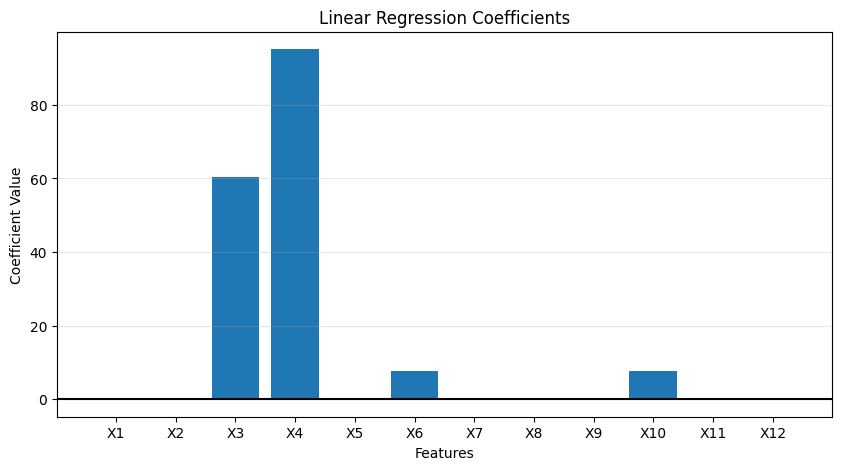

In [4]:
# Linear Regression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_coef = linear_model.coef_
linear_pred = linear_model.predict(X_test)

print("Linear Regression R²:", r2_score(y_test, linear_pred))
print("Linear Regression MSE:", mean_squared_error(y_test, linear_pred))

# Plot Linear Regression coefficients
plt.figure(figsize=(10,5))
plt.bar(feature_names, linear_coef)
plt.axhline(0, color="black")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.title("Linear Regression Coefficients")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [5]:
# LASSO Regression alpha = 0.1

lasso_model = Lasso(alpha=0.1, max_iter=10000, random_state=42)
lasso_model.fit(X_train, y_train)

lasso_coef = lasso_model.coef_
lasso_pred = lasso_model.predict(X_test)

print("\nLASSO Regression R²:", r2_score(y_test, lasso_pred))
print("LASSO Regression MSE:", mean_squared_error(y_test, lasso_pred))


LASSO Regression R²: 0.9999837529899559
LASSO Regression MSE: 0.2196286030365475


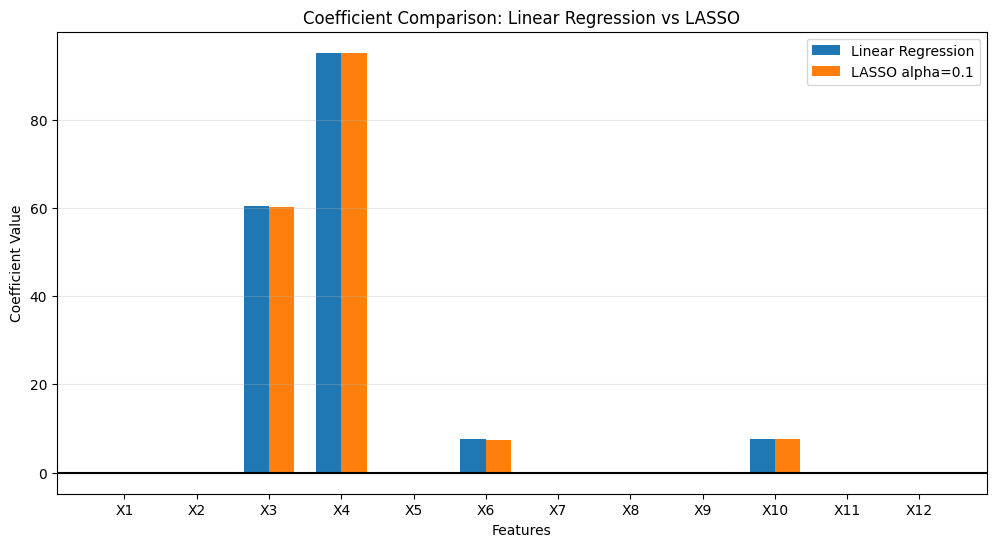

In [6]:
# Compare Linear vs LASSO coefficients

x_axis = np.arange(len(feature_names))
width = 0.35

plt.figure(figsize=(12,6))
plt.bar(x_axis - width/2, linear_coef, width, label="Linear Regression")
plt.bar(x_axis + width/2, lasso_coef, width, label="LASSO alpha=0.1")

plt.axhline(0, color="black")
plt.xticks(x_axis, feature_names)
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.title("Coefficient Comparison: Linear Regression vs LASSO")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

In [7]:
# Try different alpha values

alphas = [0.01, 0.1, 1.0]

print("\nLASSO with Different Alpha Values")
print("-" * 40)

for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    r2 = r2_score(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    non_zero_features = np.sum(model.coef_ != 0)

    print(f"Alpha: {alpha}")
    print(f"R² Score: {r2}")
    print(f"MSE: {mse}")
    print(f"Number of selected features: {non_zero_features}")
    print("Coefficients:", model.coef_)
    print("-" * 40)


LASSO with Different Alpha Values
----------------------------------------
Alpha: 0.01
R² Score: 0.9999921073545558
MSE: 0.10669352012946622
Number of selected features: 7
Coefficients: [-0.00000000e+00  3.25286993e-02  6.03714436e+01  9.51215701e+01
  0.00000000e+00  7.49429515e+00  0.00000000e+00 -1.59740823e-02
 -1.42716009e-03  7.64621839e+00 -0.00000000e+00 -0.00000000e+00]
----------------------------------------
Alpha: 0.1
R² Score: 0.9999837529899559
MSE: 0.2196286030365475
Number of selected features: 4
Coefficients: [-0.          0.         60.22073262 94.98891409  0.          7.38160172
 -0.         -0.          0.          7.53593603 -0.         -0.        ]
----------------------------------------
Alpha: 1.0
R² Score: 0.9993105552173358
MSE: 9.319979127002435
Number of selected features: 4
Coefficients: [-0.         -0.         58.74264527 93.66150743  0.          6.26372209
 -0.         -0.          0.          6.42248689 -0.         -0.        ]
------------------------

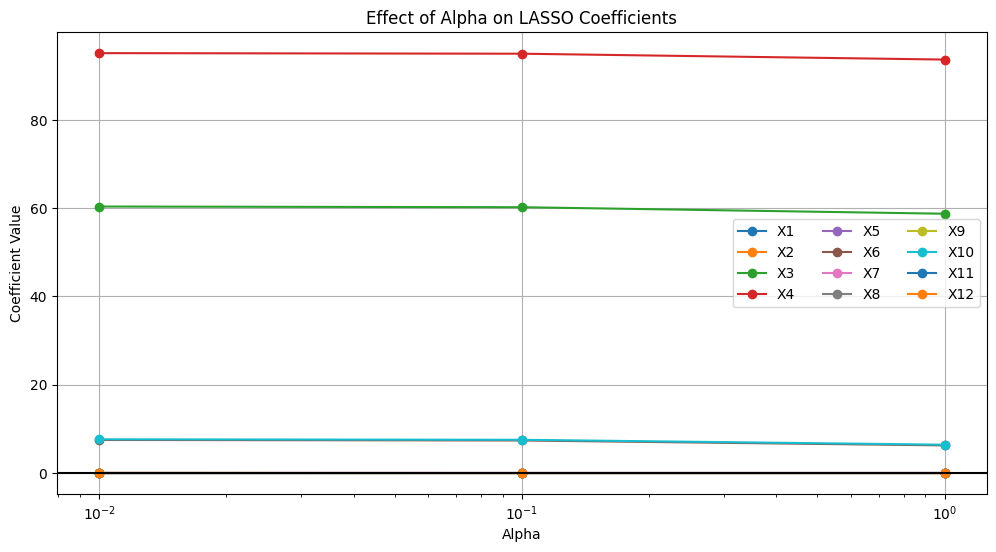

In [8]:
# Visualise coefficient changes by alpha


alphas = [0.01, 0.1, 1.0]
coef_list = []

for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    model.fit(X_train, y_train)
    coef_list.append(model.coef_)

coef_array = np.array(coef_list)

plt.figure(figsize=(12,6))

for i in range(len(feature_names)):
    plt.plot(alphas, coef_array[:, i], marker="o", label=feature_names[i])

plt.xscale("log")
plt.axhline(0, color="black")
plt.xlabel("Alpha")
plt.ylabel("Coefficient Value")
plt.title("Effect of Alpha on LASSO Coefficients")
plt.legend(ncol=3)
plt.grid(True)
plt.show()

## What you should observe:

As alpha increases, LASSO applies stronger regularisation. This means some feature coefficients become exactly zero. These zero coefficients show that LASSO has removed less useful features from the model.